# Hurricane · Solar — M4 loss & metrics: compound-Poisson MC → EAL / VaR / PML / TVaR

**Peril:** Tropical cyclone / hurricane (WIND) · **Cell:** × Solar PV · **Layer:** M4 (loss & metrics)

**Magnitude metric:** the **3-second peak gust (mph)** drives the per-event losses sampled here; outputs are
**annual loss** (% of TIV + $). *(Surge/rain = flood's `[C]`/`[F]`, cross-linked, not modeled here.)*

**Data source:** M3 per-event conditional losses (`tc_m3_damage.parquet`), M1 per-site rate λ
(`tc_m1_site_summary.parquet`, observed-anchored), and per-site TIV (`tc_m0_sites.json`).

**What this notebook does:** turns M3's per-event conditional losses into a **sampled annual loss distribution** and
reads the risk metrics off it — **EAL / VaR / PML / TVaR**, as **% of TIV (headline) + $** — on the shared
**compound-Poisson Monte-Carlo** engine. Each simulated year draws `N ~ Poisson(λ)` storms, resamples each storm's
loss from the empirical per-event severity, and sums within the year; metrics come off the sampled annual-loss
vector (never the expected-loss shortcut). The hurricane catalog is **event-based** (real storm objects), so it
feeds the MC directly — like hail, with no RP-curve bridge. It excludes the cross-link rider sites (Discovery, LA3
West Baton Rouge) that ride the hurricane pipeline only to supply a wind leg for flood-coastal's compound combine
(JD-FL-16), keeping Everglades + Hayhurst as the example, and emits the metrics table + EP-curve plot + manifest.

**Reported honestly (the caveats carried in):**
- **% of TIV is the headline** (robust to the estimated farm value; dollars are secondary — ATC-16).
- **A single point on the chosen curve** (`tracker_stow`), consistent with the other cells — not a stow↔stow-fail
  range, because both are **provisional placeholders** ([ATC-14](../../../../docs/plans/hurricane/assumptions.md)) to
  be replaced; a range between throwaway curves would overstate the precision. Curve flagged in prose (dominant
  uncertainty); `stow-fail` kept only as a recorded internal sensitivity.
- **PML reported to 500-yr** (well inside the ~1,000-yr catalog-depth limit; deeper isn't resolvable — JD-TC-8).
- **EAL carries ±~17% frequency uncertainty** (the rate rests on ~33 observed storms).
- **Hayhurst = the true-zero control** (λ=0 → exactly zero).

> Plan: [`m4_loss_metrics.md`](../../../../docs/plans/hurricane/m4_loss_metrics.md) · prior: [M3](../m3_damage/01_damage.ipynb).

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "AGENTS.md").exists():
    ROOT = ROOT.parent
DATA = ROOT / "data" / "hurricane"
RPS = [100, 250, 500]                 # PML return periods — capped at 500 (inside the ~1000-yr catalog limit)
N_YEARS = 500_000
FREQ_REL_UNC = 0.17                   # ±17% from the 33-storm observed sample (√33/33)
print("repo root:", ROOT)

repo root: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling


## Source & provenance (pin it, cache it)

- **M3 per-event conditional losses** (`data/hurricane/tc_m3_damage.parquet`) — the severity samples.
- **M1 per-site rate λ** (`data/hurricane/tc_m1_site_summary.parquet`) — the observed-anchored frequency.
- **TIV** (`tc_m0_sites.json`, $/MW estimate). **Engine:** shared compound-Poisson MC (event-based, no RP bridge).
  **Reproducibility:** metrics + EP curve persist to `data/hurricane/tc_m4_*` (+ manifest).

## Assumptions (this layer)

**ATC-15** event model = **storm-resolved compound-Poisson MC**, metrics off the *sampled* annual-loss vector (never
the expected-loss shortcut) · **ATC-2** physical loss only · **ATC-16** **% of TIV is the headline**; $ via the
$/MW TIV estimate (secondary) · **ATC-18** climate non-stationarity carried as an overlay, not embedded · annual
PML bounded at 100% TIV; reported to ~500-yr (catalog depth). Full register:
[`assumptions.md`](../../../../docs/plans/hurricane/assumptions.md).

## 1 · Inputs — per-event loss fractions + the calibrated rate λ

In [2]:
m3 = pd.read_parquet(DATA / "tc_m3_damage.parquet")
# Exclude cross-link rider sites (Discovery, LA3 — appended for flood-coastal's compound combine, JD-FL-16).
# They ride the hurricane pipeline to supply a wind leg; they are NOT hurricane proving sites and must stay
# out of the hurricane headline (Everglades + Hayhurst remain the example). Per the JD-FL-16 convention every
# rider carries a `cross-link …` role (LA3's all-three FLOOD identity lives in flood's own files; here it is a
# cross-link rider), so a single startswith("cross-link") filter excludes them all — durable for future riders.
m3 = m3[~m3["site_role"].astype(str).str.startswith("cross-link")].copy()
summ = pd.read_parquet(DATA / "tc_m1_site_summary.parquet")     # carries lambda_per_yr per site
summ = summ[~summ["role"].astype(str).str.startswith("cross-link")].copy()
sites = {s["name"]: s for s in json.load(open(DATA / "tc_m0_sites.json"))["sites"]
         if not str(s.get("role", "")).startswith("cross-link")}   # drop appended flood-coastal sites (JD-FL-16)
lam = {r["site"]: float(r["lambda_per_yr"]) for _, r in summ.iterrows()}
print("per-site λ (events/yr):", {k: round(v, 4) for k, v in lam.items()})
print("per-event loss fraction (conditional_DR) is % of TIV; value_exposed_fraction already folded in (=1.0)")

per-site λ (events/yr): {'Hayhurst Texas Solar': 0.0, 'Everglades Solar Energy Center': 0.1908}
per-event loss fraction (conditional_DR) is % of TIV; value_exposed_fraction already folded in (=1.0)


## 2 · The shared compound-Poisson MC + metrics

Each simulated year draws `N ~ Poisson(λ)` storms; each storm's loss is resampled from the empirical per-event
severity (the M3 conditional losses); losses **sum within the year**. Metrics read off the sampled annual-loss
vector — never the expected-loss shortcut (the old model's cardinal error).

In [3]:
rng = np.random.default_rng(20260620)

def simulate(loss_fracs, lam_site, n_years=N_YEARS):
    if lam_site <= 0 or len(loss_fracs) == 0:
        return np.zeros(n_years), np.zeros(n_years)
    n_per_year = rng.poisson(lam_site, n_years)
    total = int(n_per_year.sum())
    draws = rng.choice(loss_fracs, size=total, replace=True)
    year_id = np.repeat(np.arange(n_years), n_per_year)
    annual = np.zeros(n_years)
    np.add.at(annual, year_id, draws)     # AEP = annual aggregate (sum of a year's storms), bounded at 100% TIV below
    oep = np.zeros(n_years)
    if total:
        np.maximum.at(oep, year_id, draws)   # OEP = the year's single largest storm (occurrence basis)
    return np.minimum(annual, 1.0), np.minimum(oep, 1.0)   # bounded at 100% of TIV (can't lose more than the asset)

def metrics_of(v):
    var99 = np.percentile(v, 99)
    return {"EAL": v.mean(), "VaR99": var99, "TVaR99": v[v >= var99].mean() if (v >= var99).any() else 0.0,
            **{f"PML{T}": np.percentile(v, 100 * (1 - 1 / T)) for T in RPS}}

def twin_metrics(aep, oep):               # house-standard metric set, native units (fraction of TIV)
    var99 = np.percentile(aep, 99)
    return {
        "EAL":                  float(aep.mean()),
        "VaR95 (AEP-PML20)":    float(np.quantile(aep, 0.95)),
        "VaR99 (AEP-PML100)":   float(var99),                  # this IS PML100 — one entry, both names
        "VaR99.6 (AEP-PML250)": float(np.quantile(aep, 0.996)),
        "PML500 (AEP-99.8)":    float(np.quantile(aep, 0.998)),
        "TVaR99":               float(aep[aep >= var99].mean()) if (aep >= var99).any() else 0.0,
        "OEP-PML100":           float(np.quantile(oep, 0.99)),  # per-EVENT (largest single storm/yr), not per-year
    }

## 3 · Run — both sites × both (provisional) curves → the loss table

In [4]:
rows = []
ep_curves = {}
oep_curves = {}
for nm, s in sites.items():
    tiv = s["tiv_usd"]; lm = lam.get(nm, 0.0)
    g = m3[m3.site == nm]
    for label, col in [("stow (headline)", "conditional_DR"), ("stow-fail (sensitivity)", "conditional_DR_stowfail")]:
        fr = g[col].values
        annual, oep = simulate(fr, lm)
        ep_curves[(nm, label)] = annual
        oep_curves[(nm, label)] = oep
        m = metrics_of(annual)
        rows.append({"site": nm, "curve": label, "lambda": lm, "tiv_usd": tiv,
                     "EAL_pct": m["EAL"]*100, "EAL_usd": m["EAL"]*tiv,
                     "VaR99_pct": m["VaR99"]*100, "TVaR99_pct": m["TVaR99"]*100,
                     **{f"PML{T}_pct": m[f"PML{T}"]*100 for T in RPS},
                     **{f"PML{T}_usd": m[f"PML{T}"]*tiv for T in RPS}})
M = pd.DataFrame(rows)
pd.set_option("display.width", 200)
print("% of TIV:")
print(M[["site", "curve", "EAL_pct", "VaR99_pct", "PML100_pct", "PML250_pct", "PML500_pct", "TVaR99_pct"]].round(2).to_string(index=False))
print("\n$ (secondary — rests on the $/MW TIV estimate):")
print(M[["site", "curve", "EAL_usd", "PML100_usd", "PML500_usd"]].round(0).to_string(index=False))

% of TIV:
                          site                   curve  EAL_pct  VaR99_pct  PML100_pct  PML250_pct  PML500_pct  TVaR99_pct
          Hayhurst Texas Solar         stow (headline)     0.00       0.00        0.00        0.00        0.00         0.0
          Hayhurst Texas Solar stow-fail (sensitivity)     0.00       0.00        0.00        0.00        0.00         0.0
Everglades Solar Energy Center         stow (headline)     2.23      31.42       31.42       37.41       41.47        37.3
Everglades Solar Energy Center stow-fail (sensitivity)     4.08      47.02       47.02       55.77       66.21        57.0

$ (secondary — rests on the $/MW TIV estimate):
                          site                   curve   EAL_usd  PML100_usd  PML500_usd
          Hayhurst Texas Solar         stow (headline)       0.0         0.0         0.0
          Hayhurst Texas Solar stow-fail (sensitivity)       0.0         0.0         0.0
Everglades Solar Energy Center         stow (headline) 2459

## 4 · The headline — a single point (the chosen curve), consistent with the other cells

Like hail / wildfire / convective_wind, the headline is a **point estimate** on the chosen curve
(`tracker_stow`) — *not* a stow↔stow-fail range. Reason: **both are provisional placeholders to be replaced**, so a
"range" between two throwaway curves would imply a meaningful uncertainty band it isn't. The provisional curve is
flagged in prose (the dominant uncertainty), exactly as the other cells do. The **±17% frequency** note is a
*genuine* uncertainty (the 33-storm rate sample) and is kept. `stow-fail` stays only as a **recorded internal
sensitivity**, not the headline.

In [5]:
hi = "Everglades Solar Energy Center"
stow = M[(M.site == hi) & (M.curve.str.startswith("stow (")) ].iloc[0]
fail = M[(M.site == hi) & (M.curve.str.startswith("stow-fail"))].iloc[0]
eal_lo, eal_hi = stow.EAL_pct*(1-FREQ_REL_UNC), stow.EAL_pct*(1+FREQ_REL_UNC)
print(f"HEADLINE — {hi} (hurricane WIND only, % of TIV, curve=tracker_stow [PROVISIONAL]):")
print(f"  EAL:     {stow.EAL_pct:.2f}%   (~{eal_lo:.2f}–{eal_hi:.2f}% incl. ±17% storm-rate uncertainty)")
print(f"  PML100:  {stow.PML100_pct:.1f}%")
print(f"  PML250:  {stow.PML250_pct:.1f}%")
print(f"  PML500:  {stow.PML500_pct:.1f}%   (annual AEP, bounded 100% TIV; deeper than 500-yr not resolvable)")
print(f"  TVaR99:  {stow.TVaR99_pct:.1f}%")
print(f"\n  recorded sensitivity (NOT headline): a harsher provisional curve gives EAL {fail.EAL_pct:.2f}%, PML500 {fail.PML500_pct:.1f}%")
print(f"\nBaseline Hayhurst: EAL {M[(M.site!=hi)].EAL_pct.max():.3f}% (true-zero control — λ=0)")
print("\n⚠ EAL is high and CURVE-DRIVEN — the provisional library curve (esp. mounting onset x0 120 mph) damages at")
print("  moderate gusts; the real number awaits the replacement curve + a loss-side benchmark (Hazus/NRI). Hazard")
print("  side is independently validated (ASCE); the LOSS side is the soft part.")

HEADLINE — Everglades Solar Energy Center (hurricane WIND only, % of TIV, curve=tracker_stow [PROVISIONAL]):
  EAL:     2.23%   (~1.85–2.60% incl. ±17% storm-rate uncertainty)
  PML100:  31.4%
  PML250:  37.4%
  PML500:  41.5%   (annual AEP, bounded 100% TIV; deeper than 500-yr not resolvable)
  TVaR99:  37.3%

  recorded sensitivity (NOT headline): a harsher provisional curve gives EAL 4.08%, PML500 66.2%

Baseline Hayhurst: EAL 0.000% (true-zero control — λ=0)

⚠ EAL is high and CURVE-DRIVEN — the provisional library curve (esp. mounting onset x0 120 mph) damages at
  moderate gusts; the real number awaits the replacement curve + a loss-side benchmark (Hazus/NRI). Hazard
  side is independently validated (ASCE); the LOSS side is the soft part.


## 5 · Known-answer checks

In [6]:
ev = M[M.site == hi]
# house-standard twin blocks for the headline (Everglades, tracker_stow) — fraction-of-TIV → $ and % of TIV
hi_tiv = sites[hi]["tiv_usd"]
tw = twin_metrics(ep_curves[(hi, "stow (headline)")], oep_curves[(hi, "stow (headline)")])
metrics_usd = {k: round(v * hi_tiv, 2) for k, v in tw.items()}
metrics_pct_of_tiv = {k: round(v * 100, 4) for k, v in tw.items()}
checks = {
    "Hayhurst all-zero (true-zero control)": float(M[M.site != hi][["EAL_pct"]+[f"PML{T}_pct" for T in RPS]].abs().max().max()) == 0.0,
    "AEP ≥ OEP every year (annual total ≥ its largest single storm)":
        bool((ep_curves[(hi, "stow (headline)")] + 1e-12 >= oep_curves[(hi, "stow (headline)")]).all()),
    "OEP-PML100 ≤ AEP-PML100 (occurrence ≤ aggregate)": tw["OEP-PML100"] <= tw["VaR99 (AEP-PML100)"] + 1e-12,
    "TVaR99 ≥ VaR99 (tail-average past the quantile)": tw["TVaR99"] >= tw["VaR99 (AEP-PML100)"] - 1e-12,
    "PML500 ≥ PML250 ≥ PML100 ≥ EAL > 0 (twin-block monotone)":
        tw["PML500 (AEP-99.8)"] >= tw["VaR99.6 (AEP-PML250)"] >= tw["VaR99 (AEP-PML100)"] >= tw["EAL"] > 0,
    "twin-block unit consistency: usd/TIV*100 == pct_of_tiv (to rounding)":
        all(abs(metrics_usd[k] / hi_tiv * 100 - metrics_pct_of_tiv[k]) < 1e-3 for k in tw),
    "stow-fail ≥ stow on every metric (worse is worse)":
        bool((fail[["EAL_pct","PML100_pct","PML250_pct","PML500_pct"]].values >= stow[["EAL_pct","PML100_pct","PML250_pct","PML500_pct"]].values - 1e-6).all()),
    "PML monotonic in return period": bool((ev["PML500_pct"] >= ev["PML250_pct"]).all() and (ev["PML250_pct"] >= ev["PML100_pct"]).all()),
    "EAL ≈ λ·mean(per-event DR) (compound-Poisson identity)":
        abs(stow.EAL_pct/100 - lam[hi]*m3[m3.site==hi].conditional_DR.mean()) < 5e-3,
    "all annual metrics ≤ 100% of TIV (aggregate bound)": float(ev[[f"PML{T}_pct" for T in RPS]+["VaR99_pct","TVaR99_pct"]].max().max()) <= 100.0,
    "stow occurrence-PML ≤ single-event DR cap (~48%); stow-fail tail exceeds it via multi-storm years (aggregate)":
        (stow.PML500_pct <= 48.5) and (fail.PML500_pct > 48.5),
    "EAL > 0 at the high site (material peril)": stow.EAL_pct > 0,
}
for k, v in checks.items():
    print(f"  {'✅' if v else '❌'}  {k}")
assert all(checks.values()), "an M4 check failed"
print("\nall M4/01 known-answer checks pass ✅")

  ✅  Hayhurst all-zero (true-zero control)
  ✅  AEP ≥ OEP every year (annual total ≥ its largest single storm)
  ✅  OEP-PML100 ≤ AEP-PML100 (occurrence ≤ aggregate)
  ✅  TVaR99 ≥ VaR99 (tail-average past the quantile)
  ✅  PML500 ≥ PML250 ≥ PML100 ≥ EAL > 0 (twin-block monotone)
  ✅  twin-block unit consistency: usd/TIV*100 == pct_of_tiv (to rounding)
  ✅  stow-fail ≥ stow on every metric (worse is worse)
  ✅  PML monotonic in return period
  ✅  EAL ≈ λ·mean(per-event DR) (compound-Poisson identity)
  ✅  all annual metrics ≤ 100% of TIV (aggregate bound)
  ✅  stow occurrence-PML ≤ single-event DR cap (~48%); stow-fail tail exceeds it via multi-storm years (aggregate)
  ✅  EAL > 0 at the high site (material peril)

all M4/01 known-answer checks pass ✅


## 6 · Plot — annual-loss exceedance (EP) curve, the two-curve band

wrote /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/hurricane/tc_m4_ep_curve.png


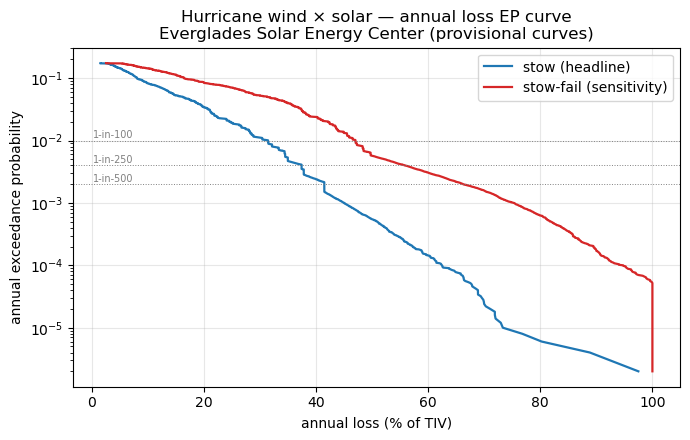

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for label, color in [("stow (headline)", "tab:blue"), ("stow-fail (sensitivity)", "tab:red")]:
    v = np.sort(ep_curves[(hi, label)])[::-1]
    ep = np.arange(1, len(v)+1) / len(v)
    nz = v > 0
    ax.plot(v[nz]*100, ep[nz], color=color, lw=1.6, label=label)
for T in RPS:
    ax.axhline(1/T, color="grey", ls=":", lw=0.7); ax.text(0.2, 1/T*1.1, f"1-in-{T}", fontsize=7, color="grey")
ax.set_yscale("log"); ax.set_xlabel("annual loss (% of TIV)"); ax.set_ylabel("annual exceedance probability")
ax.set_title(f"Hurricane wind × solar — annual loss EP curve\n{hi} (provisional curves)")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(DATA / "tc_m4_ep_curve.png", dpi=110)
print("wrote", DATA / "tc_m4_ep_curve.png")

## 7 · Emit — the metrics + manifest

In [8]:
M.to_parquet(DATA / "tc_m4_loss_metrics.parquet", index=False)
manifest = {
    "notebook": "hurricane/solar/m4_loss_metrics/01_loss_metrics",
    "engine": "shared compound-Poisson MC (event-based, no RP bridge); N_years=%d" % N_YEARS,
    "headline_metric": "% of TIV (dollars secondary — $/MW TIV estimate, ATC-16)",
    "high_site": hi,
    "headline_curve": "tracker_stow (PROVISIONAL) — point estimate, consistent with other cells (not a stow range)",
    "headline_pct_of_TIV": {
        "EAL": round(stow.EAL_pct, 2),
        "EAL_with_freq_unc": [round(eal_lo, 2), round(eal_hi, 2)],
        "PML100": round(stow.PML100_pct, 1),
        "PML250": round(stow.PML250_pct, 1),
        "PML500": round(stow.PML500_pct, 1),
        "TVaR99": round(stow.TVaR99_pct, 1),
    },
    "recorded_sensitivity_not_headline": {"harsher_provisional_curve_EAL": round(fail.EAL_pct, 2),
                                          "harsher_provisional_curve_PML500": round(fail.PML500_pct, 1)},
    # house-standard twin blocks (headline: Everglades, tracker_stow) — identical keys, block name carries the unit
    "metrics_usd": metrics_usd,
    "metrics_pct_of_tiv": metrics_pct_of_tiv,
    "occurrence_basis_note": "OEP-PML100 = per-EVENT (largest single storm/yr); AEP metrics = annual aggregate (sum of a year's storms). For Everglades (λ≈0.19) OEP < AEP where a year carries >1 storm.",
    "baseline": "Hayhurst EAL = 0 (true-zero control, λ=0)",
    "caveats": [
        "LOSS side is curve-limited (provisional ATC-14 curves) — the dominant uncertainty; hazard side is ASCE-validated",
        "EAL is high & curve-driven (mounting onset x0 120) — awaits replacement curve + loss benchmark (Hazus/NRI)",
        "PML reported to 500-yr only (~1000-yr catalog limit); capped at ~48% DR (no total-loss representation)",
        "EAL ±17% from the 33-storm rate sample; $ figures ride on the $/MW TIV estimate",
    ],
    "outputs": {"metrics_parquet": "data/hurricane/tc_m4_loss_metrics.parquet", "ep_curve_png": "data/hurricane/tc_m4_ep_curve.png"},
}
(DATA / "tc_m4_metrics_manifest.json").write_text(json.dumps(manifest, indent=2))
print("wrote", DATA / "tc_m4_loss_metrics.parquet", "and manifest")

wrote /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/hurricane/tc_m4_loss_metrics.parquet and manifest


## Takeaways — the pipeline is complete (M0→M4)

- **Hurricane × solar V1 runs end-to-end** — RAFT catalog → Holland field → field-intensity coupling → damage →
  **EAL / VaR / PML / TVaR** (% of TIV + $), on the shared MC engine.
- **Headline is a point on the chosen provisional curve** (+ ±17% rate note), consistent with the other cells;
  the provisional curve is the dominant uncertainty, flagged for replacement. Hayhurst = 0.
- **The hazard side is independently validated** (ASCE, 90 kt==obs); **the loss side is the soft part** — curve-driven,
  awaiting the replacement fragility curve and a **loss-side benchmark** (Hazus/NRI) as its own second opinion.
- **Architectural dividends banked:** field-intensity coupling built (degenerate on solar, full in the built wind-farm cell);
  `event_family_id` stamped → coastal flood attaches now (active cross-link); pluvial-TC later — via the shared RAFT catalog.

**Next (beyond V1):** swap the provisional damage curve + add a Hazus/NRI loss benchmark. The wind-farm cell is built
(per-turbine field-intensity, reusing this catalog + convective wind's turbine curve).